In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
# for plots
from matplotlib import rc

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

current_path=os.getcwd()
object1_filename=current_path+'/BHM_spectra/spec-015173-59381-4351098892.fits'
object1_data = Table.read(object1_filename, format='fits',hdu=1)

In [4]:
object1_data

FLUX,LOGLAM,IVAR,AND_MASK,OR_MASK,WDISP,SKY,MODEL,WRESL
10^-17 ergs/s/cm^2/Angs,log10(Angs),,,,Pixels,10^-17 ergs/s/cm^2/Angs,,Angs
float32,float32,float32,int32,int32,float32,float32,float32,float32
57.025764,3.5523,0.0,88080384,88080384,0.0,0.0,20.047207,0.0
57.025764,3.5523999,0.0,88080384,88080384,0.0,0.0,20.061258,0.0
57.025764,3.5525,0.0,88080384,88080384,0.0,0.0,19.964983,0.0
57.025764,3.5526,0.0,88080384,88080384,0.0,0.0,19.916162,0.0
57.025764,3.5527,0.0,88080384,88080384,0.0,0.0,19.874899,0.0
57.025764,3.5528,0.0,88080384,88080384,0.0,0.0,19.90086,0.0
57.025764,3.5529,0.0,88080384,88080384,0.0,0.0,19.998386,0.0
57.025764,3.553,0.0,88080384,88080384,0.0,0.0,20.031792,0.0


In [5]:
object1_data['WAVELENGTH']=10.0**object1_data['LOGLAM']

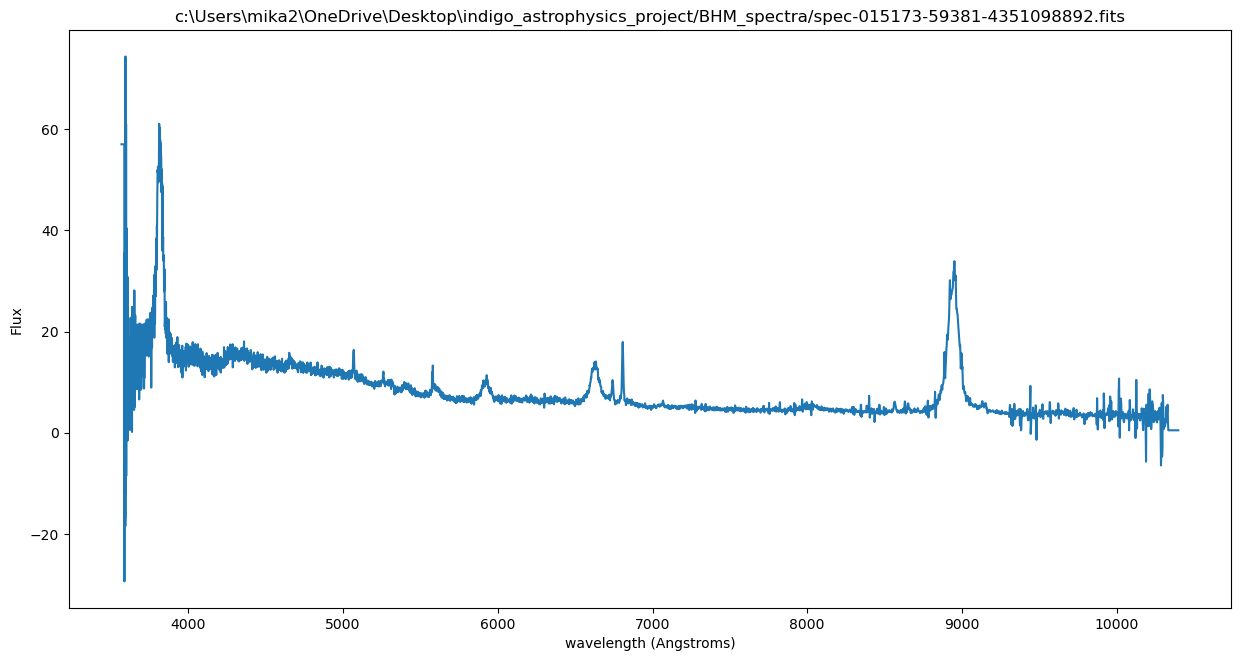

In [6]:
plt.figure(figsize=(15,7.5))
plt.plot(object1_data['WAVELENGTH'],object1_data['FLUX'])
plt.title(object1_filename)
plt.xlabel('wavelength (Angstroms)')
plt.ylabel('Flux')
plt.show()

In [7]:
object1_mask_pixels =(object1_data['AND_MASK']==0)

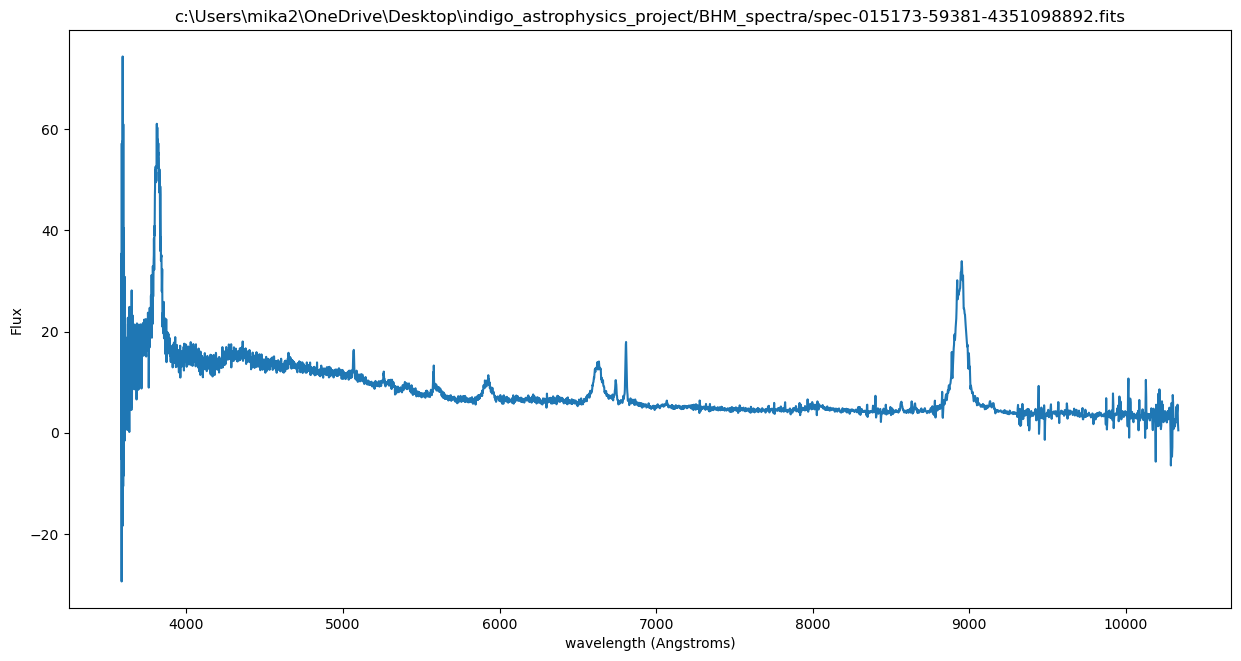

In [8]:
plt.figure(figsize=(15,7.5))
plt.plot(object1_data[object1_mask_pixels]['WAVELENGTH'],object1_data[object1_mask_pixels]['FLUX'])
plt.title(object1_filename)
plt.xlabel('wavelength (Angstroms)')
plt.ylabel('Flux')
plt.show()

In [10]:
object2_filename=current_path+'/BHM_spectra/spec-015301-59314-4602374937.fits'
object3_filename=current_path+'/BHM_spectra/spec-015023-59232-4555307714.fits'

# --- Object 2 ---
object2_data = Table.read(object2_filename, format='fits',hdu=1)
object2_data['WAVELENGTH']=10.0**object2_data['LOGLAM']
object2_mask_pixels =(object2_data['AND_MASK']==0)

# --- Object 3 ---
object3_data = Table.read(object3_filename, format='fits',hdu=1)
object3_data['WAVELENGTH']=10.0**object3_data['LOGLAM']
object3_mask_pixels =(object3_data['AND_MASK']==0)

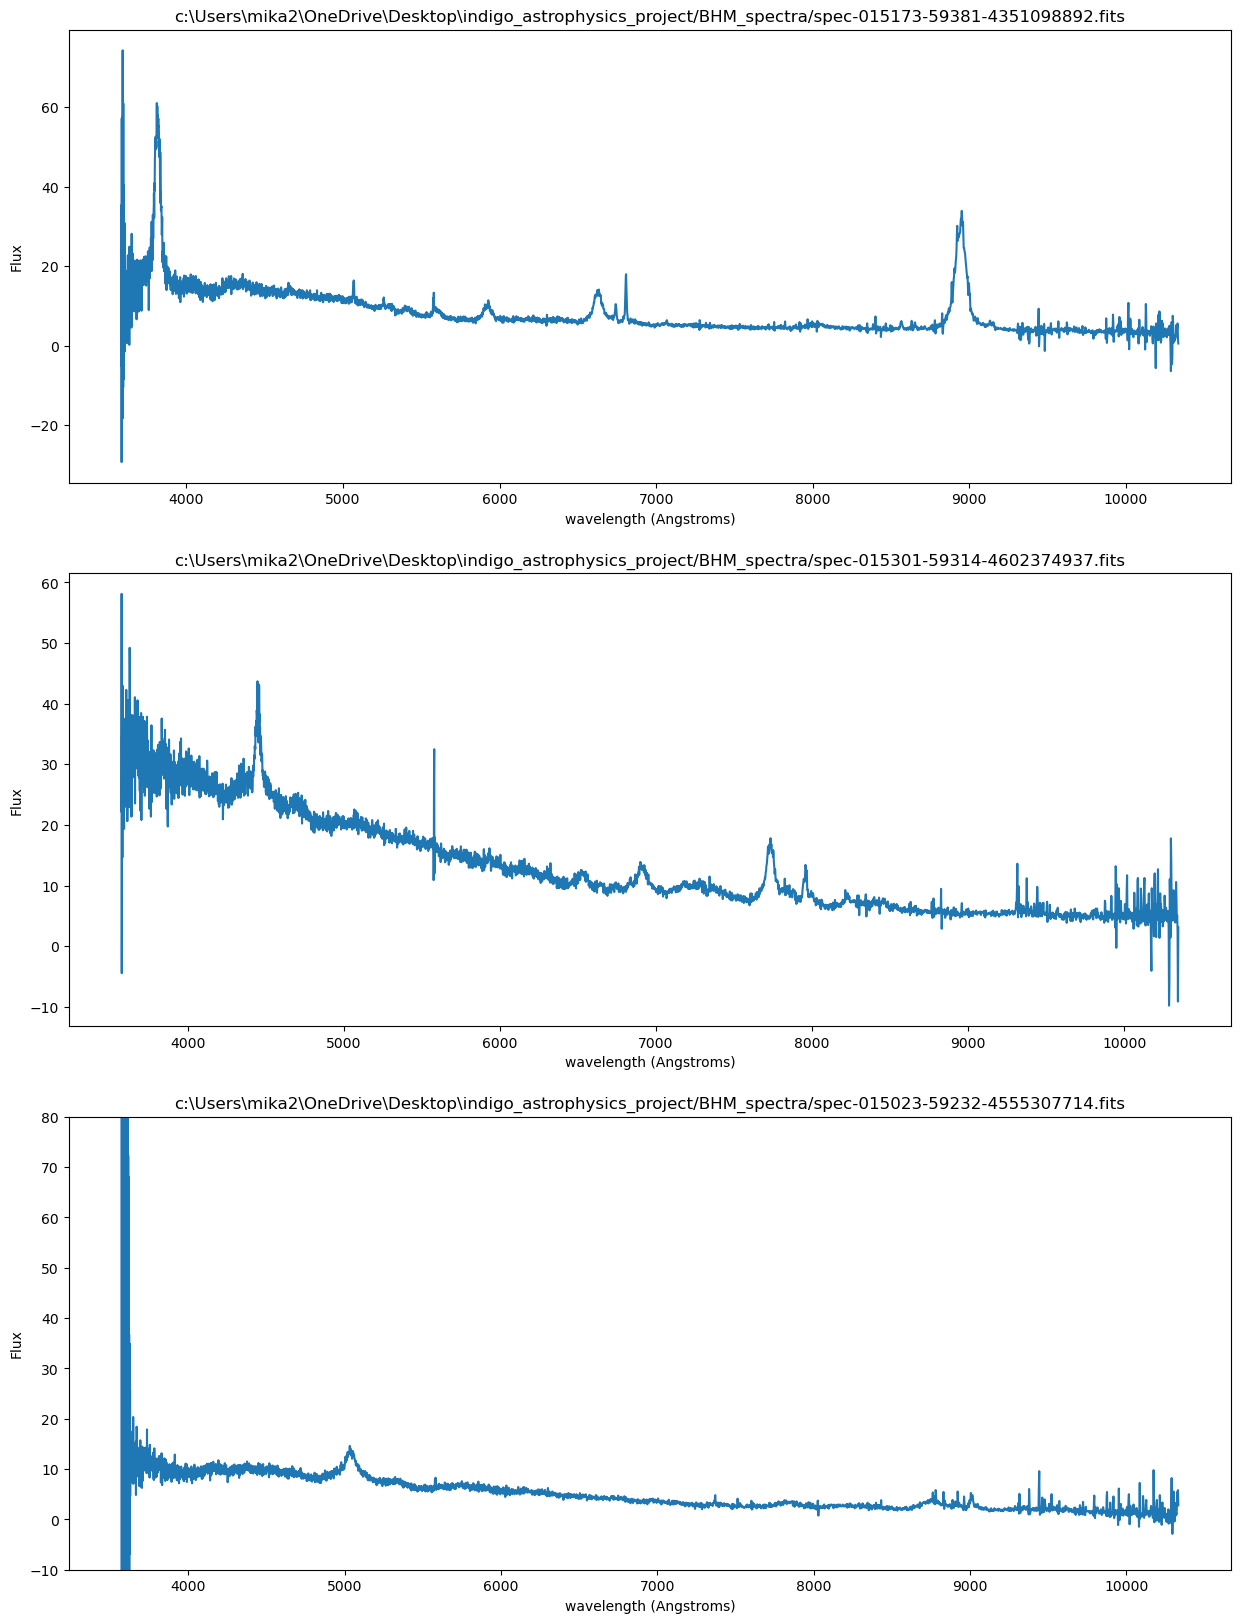

In [11]:
plt.figure(figsize=(15,20))

plt.subplot(3,1,1)
#object1 plotting code goes here
plt.plot(object1_data[object1_mask_pixels]['WAVELENGTH'],object1_data[object1_mask_pixels]['FLUX'])
plt.title(object1_filename)
plt.xlabel('wavelength (Angstroms)')
plt.ylabel('Flux')

plt.subplot(3,1,2)
#object2 plotting code goes here
plt.plot(object2_data[object2_mask_pixels]['WAVELENGTH'],object2_data[object2_mask_pixels]['FLUX'])
plt.title(object2_filename)
plt.xlabel('wavelength (Angstroms)')
plt.ylabel('Flux')

plt.subplot(3,1,3)
#object3 plotting code goes here
plt.plot(object3_data[object3_mask_pixels]['WAVELENGTH'],object3_data[object3_mask_pixels]['FLUX'])
plt.title(object3_filename)
plt.xlabel('wavelength (Angstroms)')
plt.ylabel('Flux')
# there is an issue with this spectrum at the very blue end, we can ignore it and manually change the y axis
plt.ylim(-10,80)

plt.show()

In [12]:
object1_pipeline_data = Table.read(object1_filename, format='fits',hdu=2)

In [13]:
object1_pipeline_data.colnames

['FIELD',
 'MJD',
 'OBS',
 'MJD_FINAL',
 'MJD_LIST',
 'TAI_LIST',
 'RUN2D',
 'RUN1D',
 'DESIGNS',
 'CONFIGS',
 'NEXP',
 'EXPTIME',
 'TARGET_INDEX',
 'FIBERID_LIST',
 'SPEC_FILE',
 'PROGRAMNAME',
 'SURVEY',
 'CADENCE',
 'FIRSTCARTON',
 'CARTON_TO_TARGET_PK',
 'SDSS5_TARGET_FLAGS',
 'OBJTYPE',
 'CATALOGID',
 'CATALOGID_V0',
 'CATALOGID_V0P5',
 'SDSS_ID',
 'SPECOBJID',
 'CALIBFLUX',
 'CALIBFLUX_IVAR',
 'OPTICAL_PROV',
 'MAG',
 'PSFMAG',
 'FIBER2MAG',
 'CATDB_MAG',
 'GAIA_G_MAG',
 'GRI_GAIA_TRANSFORM',
 'BP_MAG',
 'RP_MAG',
 'GAIA_ID',
 'WISE_MAG',
 'TWOMASS_MAG',
 'GUVCAT_MAG',
 'EBV',
 'EBV_TYPE',
 'FIBER_RA',
 'FIBER_DEC',
 'PLUG_RA',
 'PLUG_DEC',
 'RACAT',
 'DECCAT',
 'COORD_EPOCH',
 'PMRA',
 'PMDEC',
 'PARALLAX',
 'RA_LIST',
 'DEC_LIST',
 'DELTA_RA_LIST',
 'DELTA_DEC_LIST',
 'FIBER_OFFSET',
 'XFOCAL',
 'YFOCAL',
 'ZOFFSET',
 'LAMBDA_EFF',
 'BLUEFIBER',
 'HEALPIX',
 'HEALPIXGRP',
 'HEALPIX_PATH',
 'FIELDQUALITY',
 'EXP_DISP_MED',
 'FIELDSN2',
 'FIELDSNR2G_LIST',
 'FIELDSNR2R_LIST',
 'F

In [14]:
object1_z=object1_pipeline_data[0]['Z']
object1_z_err=object1_pipeline_data[0]['Z_ERR']
print('z='+str(object1_z)+' +/- '+str(object1_z_err))

z=0.36250922 +/- 5.620322e-05


In [15]:
# Extract redshifts for objects 2 and 3
object2_pipeline_data = Table.read(object2_filename, format='fits',hdu=2)
object2_z=object2_pipeline_data[0]['Z']
object2_z_err=object2_pipeline_data[0]['Z_ERR']
print('object2 z='+str(object2_z)+' +/- '+str(object2_z_err))

object3_pipeline_data = Table.read(object3_filename, format='fits',hdu=2)
object3_z=object3_pipeline_data[0]['Z']
object3_z_err=object3_pipeline_data[0]['Z_ERR']
print('object3 z='+str(object3_z)+' +/- '+str(object3_z_err))

# Add rest-wavelength columns: lambda_rest = lambda_obs / (1 + z)
object1_data['WAVELENGTH_REST']=object1_data['WAVELENGTH']/(1.0+object1_z)
object2_data['WAVELENGTH_REST']=object2_data['WAVELENGTH']/(1.0+object2_z)
object3_data['WAVELENGTH_REST']=object3_data['WAVELENGTH']/(1.0+object3_z)

object2 z=0.59089273 +/- 8.952365e-05
object3 z=0.8004429 +/- 0.00013543066


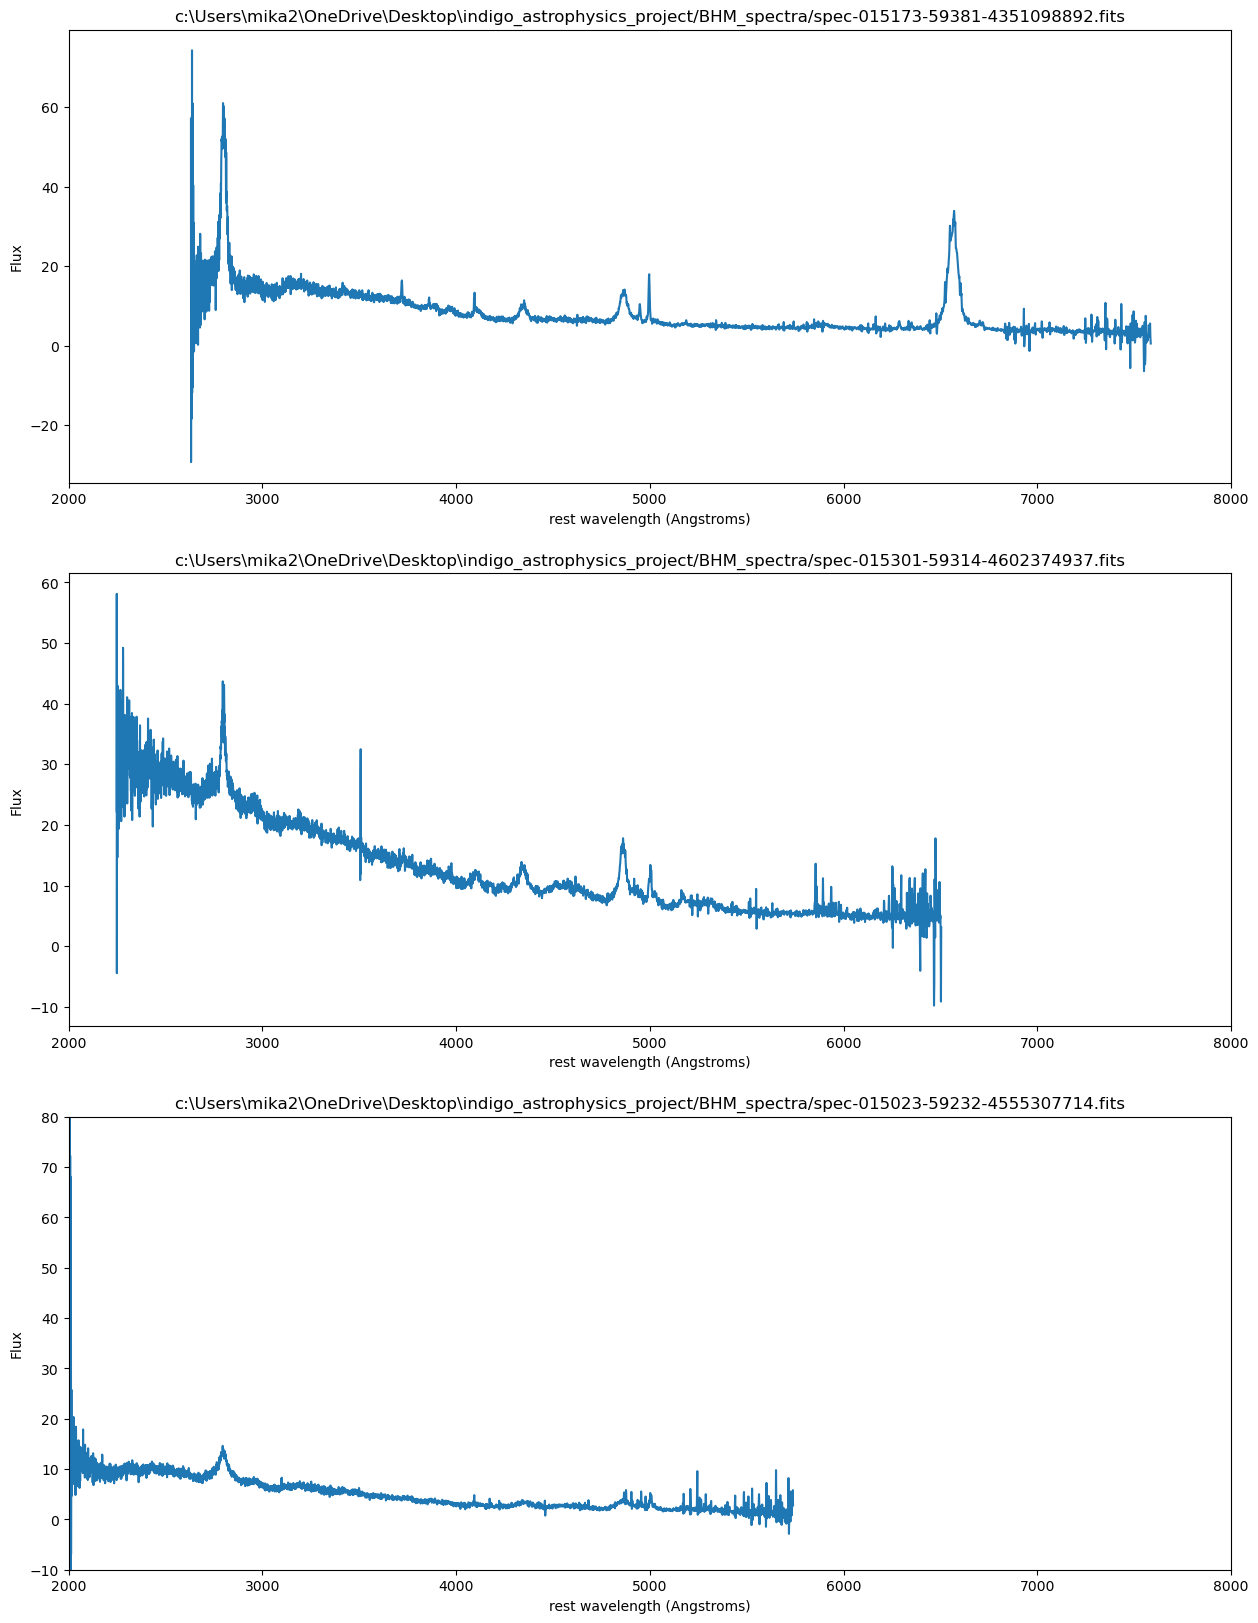

In [16]:
plt.figure(figsize=(15,20))

plt.subplot(3,1,1)
plt.plot(object1_data[object1_mask_pixels]['WAVELENGTH_REST'],object1_data[object1_mask_pixels]['FLUX'])
plt.title(object1_filename)
plt.xlabel('rest wavelength (Angstroms)')
plt.ylabel('Flux')
plt.xlim(2000,8000)

plt.subplot(3,1,2)
plt.plot(object2_data[object2_mask_pixels]['WAVELENGTH_REST'],object2_data[object2_mask_pixels]['FLUX'])
plt.title(object2_filename)
plt.xlabel('rest wavelength (Angstroms)')
plt.ylabel('Flux')
plt.xlim(2000,8000)

plt.subplot(3,1,3)
plt.plot(object3_data[object3_mask_pixels]['WAVELENGTH_REST'],object3_data[object3_mask_pixels]['FLUX'])
plt.title(object3_filename)
plt.xlabel('rest wavelength (Angstroms)')
plt.ylabel('Flux')
plt.xlim(2000,8000)
# there is an issue with this spectrum at the very blue end, we can ignore it and manually change the y axis
plt.ylim(-10,80)

plt.show()

In [17]:
object1b_filename=current_path+'/BHM_spectra/spec-7339-57518-0611.fits'
object1b_data = Table.read(object1b_filename, format='fits',hdu=1)
object1c_filename=current_path+'/BHM_spectra/spec-7339-56799-0611.fits'
object1c_data = Table.read(object1c_filename, format='fits',hdu=1)

object1b_mask_pixels =(object1b_data['and_mask']==0)
object1b_data['WAVELENGTH']=10.0**object1b_data['loglam']
object1c_mask_pixels =(object1c_data['and_mask']==0)
object1c_data['WAVELENGTH']=10.0**object1c_data['loglam']

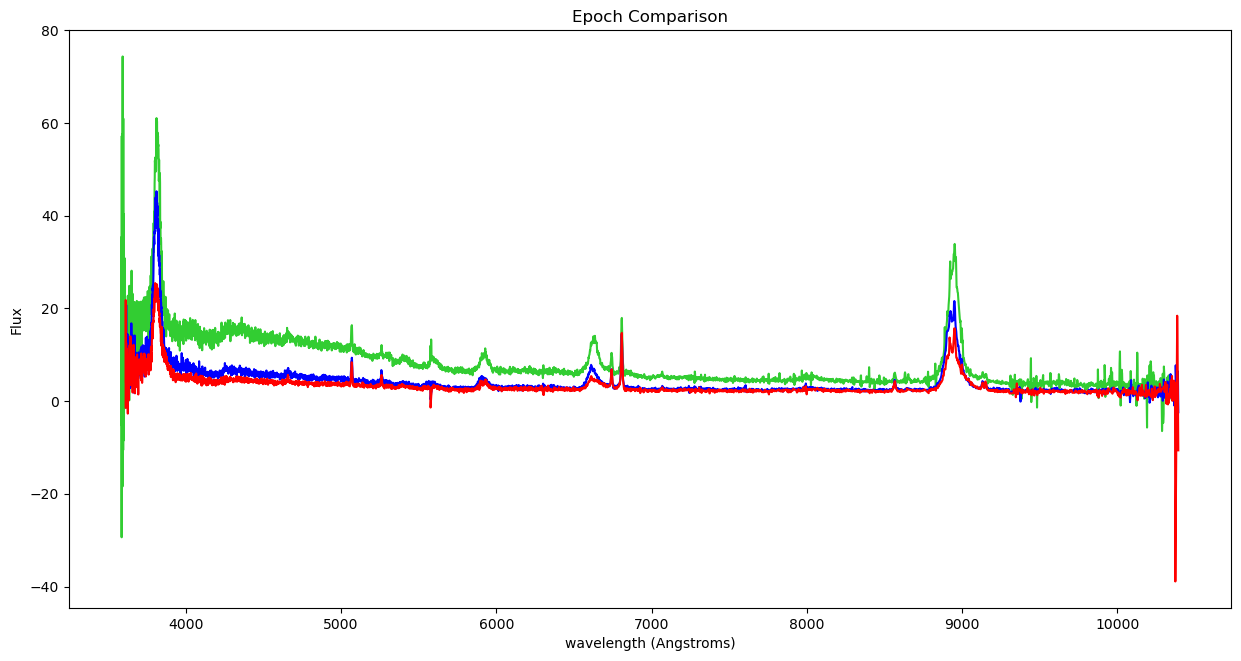

In [21]:
plt.figure(figsize=(15,7.5))
plt.plot(object1_data[object1_mask_pixels]['WAVELENGTH'],object1_data[object1_mask_pixels]['FLUX'],color='limegreen')
plt.plot(object1b_data[object1b_mask_pixels]['WAVELENGTH'],object1b_data[object1b_mask_pixels]['flux'],color='blue')
plt.plot(object1c_data[object1c_mask_pixels]['WAVELENGTH'],object1c_data[object1c_mask_pixels]['flux'],color='red')
plt.title('Epoch Comparison')
plt.xlabel('wavelength (Angstroms)')
plt.ylabel('Flux')
plt.show()

In [19]:
def mjd_to_year(mjd):
    from astropy.time import Time
    time_tmp = Time(mjd, format='mjd')
    return time_tmp.iso

2021-06-16 00:00:00.000 2016-05-10 00:00:00.000 2014-05-22 00:00:00.000


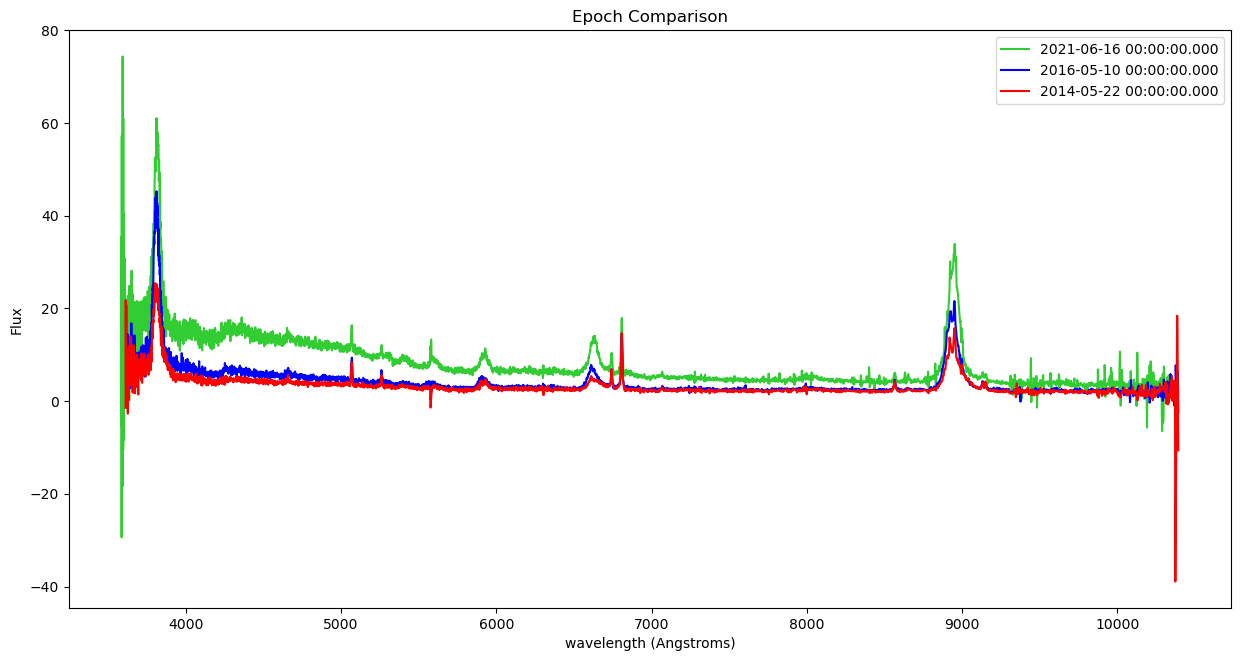

In [22]:
# The MJD is the second-to-last number in each filename (spec-plate-MJD-fiber.fits)
object1_mjd  = 59381   # spec-015173-59381-4351098892.fits
object1b_mjd = 57518   # spec-7339-57518-0611.fits
object1c_mjd = 56799   # spec-7339-56799-0611.fits

object1_date  = mjd_to_year(object1_mjd)
object1b_date = mjd_to_year(object1b_mjd)
object1c_date = mjd_to_year(object1c_mjd)
print(object1_date, object1b_date, object1c_date)

plt.figure(figsize=(15,7.5))
plt.plot(object1_data[object1_mask_pixels]['WAVELENGTH'],object1_data[object1_mask_pixels]['FLUX'],color='limegreen',label=object1_date)
plt.plot(object1b_data[object1b_mask_pixels]['WAVELENGTH'],object1b_data[object1b_mask_pixels]['flux'],color='blue',label=object1b_date)
plt.plot(object1c_data[object1c_mask_pixels]['WAVELENGTH'],object1c_data[object1c_mask_pixels]['flux'],color='red',label=object1c_date)
plt.title('Epoch Comparison')
plt.xlabel('wavelength (Angstroms)')
plt.ylabel('Flux')
plt.legend()
plt.show()

### About this notebook
This notebook was created to illustrate some of the basic principles of quasar spectra from the SDSS-V BOSS.

**Authors:** Niall Deacon  
**Editing:** John Donor  
**Last Update:** 2025 June 26

If you use astropy for published research, please cite the authors. And of course, please cite SDSS when you use their data.